# Data Cleaning
1. Dropping any rows with lsoa_code missing in street_crimes
2. Checking in lsoa_info if any lsoa code is missing from official list
3. Create month_info table
4. Delete Welsh crime data
5. Operations on lsoa_demographics as written in plan for db

In [67]:
import geopandas as gpd
import sqlite3
import pandas as d
import holidays
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/police_data.db')
cursor = conn.cursor()

In [11]:
total_rows = pd.read_sql("SELECT COUNT(*) as total FROM street_crimes;", conn).iloc[0,0]
print(f'total rows {total_rows}')

null_query = """
SELECT 
    COUNT(*) - COUNT(crime_id) as missing_crime_id,
    COUNT(*) - COUNT(month) as missing_month,
    COUNT(*) - COUNT(longitude) as missing_long,
    COUNT(*) - COUNT(latitude) as missing_lat,
    COUNT(*) - COUNT(lsoa_code) as missing_lsoa,
    COUNT(*) - COUNT(crime_type) as missing_crime,
    COUNT(*) - COUNT(last_outcome) as missing_outcome
FROM street_crimes;
"""
null_df = pd.read_sql(null_query, conn)
null_percentages = (null_df / total_rows) * 100
display(null_percentages.round(2).astype(str) + '%')

crime_type_query = """
SELECT crime_type, COUNT(*) as incident_count 
FROM street_crimes 
GROUP BY crime_type 
ORDER BY incident_count DESC;
"""
crime_df = pd.read_sql(crime_type_query, conn)
crime_df['percentage'] = ((crime_df['incident_count'] / total_rows) * 100).round(2)
display(crime_df)

total rows 94019401


,missing_crime_id,missing_month,missing_long,missing_lat,missing_lsoa,missing_crime,missing_outcome
0,31.07%,0.0%,1.49%,1.49%,3.92%,0.0%,33.89%


,crime_type,incident_count,percentage
0,Anti-social behaviour,25048350,26.64
1,Violence and sexual offences,21460754,22.83
2,Criminal damage and arson,7567187,8.05
3,Other theft,7286898,7.75
4,Vehicle crime,5807870,6.18
5,Burglary,5505345,5.86
6,Shoplifting,5145980,5.47
7,Public order,4768815,5.07
8,Other crime,3124502,3.32
9,Drugs,2542571,2.70


In [21]:
#1 dropping all rows that have no lsoa_code

#count the rows before deletion
cursor.execute('SELECT COUNT(*) FROM street_crimes;')
count_before = cursor.fetchone()
print(f'count before deletion {count_before}')

#deletes all rows where lsoa_code is empty
delete = 'DELETE FROM street_crimes WHERE lsoa_code IS NULL;'
cursor.execute(delete)
conn.commit()

#count the rows after deletion
cursor.execute("SELECT COUNT(*) FROM street_crimes;")
count_after = cursor.fetchone()
print(f'count after deletion {count_before}')

count before deletion (90337708,)
count after deletion (90337708,)


In [24]:
#2 check in lsoa_info 

#clean data gathered
clean_lsoas_df = pd.read_csv("../data/lsoa_codes.csv", usecols=['LSOA21CD', 'LSOA21NM'])
total_lsoa_set = set(clean_lsoas_df['LSOA21CD'])

#get from db all lsoas
db_lsoas_df = pd.read_sql("SELECT lsoa_code FROM lsoa_info;",  conn)
db_lsoa_set = set(db_lsoas_df['lsoa_code'])

#set difference to find which lsoa's missing from our db
missing_lsoas = total_lsoa_set - db_lsoa_set

print(f'total lsoa codes count (clean) {len(total_lsoa_set)}')
print(f'database lsoa codes count {len(db_lsoa_set)}')
print(f'number of missing lsoas {len(missing_lsoas)}')

#convert missing lsoas to series
missing_series = pd.Series(list(missing_lsoas))

#take the first letter in each code and count
code_missing = missing_series.str[0].value_counts()

print(f'missing lsoas come from {code_missing}')

total lsoa codes count (clean) 35672
database lsoa codes count 33755
number of missing lsoas 1917
missing lsoas come from W    1917
Name: count, dtype: int64


In [39]:
# 3

#getting all months
month_df = pd.read_sql("SELECT DISTINCT month FROM street_crimes ORDER BY month;", conn)

#temporary datetime column
dt_col = pd.to_datetime(month_df['month'])

#days in month built-in function by pandas
month_df['days_in_month'] = dt_col.dt.days_in_month

#mapping seasons
def get_season(month_num):
    if month_num in [3, 4, 5]: return 'spring'
    elif month_num in [6, 7, 8]: return 'summer'
    elif month_num in [9, 10, 11]: return 'fall'
    else: return 'winter'

month_df['season'] = dt_col.dt.month.apply(get_season)
print(f'number of months in database {len(month_df)}')

#holiday counts of england uk
england_holidays = holidays.UK(subdiv='England')

def count_holidays(date_obj):
    #list of all dates per month
    days_in_this_month = pd.date_range(
        start=date_obj.replace(day=1), 
        periods=date_obj.days_in_month, 
        freq='D'
    )
    #count how many of those dates exist in the official holiday dictionary
    return sum(1 for day in days_in_this_month if day in england_holidays)

month_df['holiday_count'] = dt_col.apply(count_holidays)

#write table back to database
month_df.to_sql("month_info", conn, if_exists="replace", index=False)

# create index for tft
conn.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_month_info_month ON month_info(month);")

print(month_df.head(12))

number of months in database 183
      month  days_in_month  season  holiday_count
0   2010-12             31  winter              4
1   2011-01             31  winter              2
2   2011-02             28  winter              0
3   2011-03             31  spring              0
4   2011-04             30  spring              3
5   2011-05             31  spring              2
6   2011-06             30  summer              0
7   2011-07             31  summer              0
8   2011-08             31  summer              1
9   2011-09             30    fall              0
10  2011-10             31    fall              0
11  2011-11             30    fall              0


In [63]:
#3a. save the month_info table as a csv (don't run unless you want the csv)
df_export = pd.read_sql("SELECT * FROM month_info;", conn)

csv_path = "../data/month_info.csv"
df_export.to_csv(csv_path, index=False)

print(f'exported {len(df_export)} rows')

exported 183 rows


In [50]:
#4 drop all Welsh crime from street_crimes tables

#checking how many rows before deleting 
cursor.execute("SELECT COUNT(*) FROM street_crimes;")
count_before = cursor.fetchone()[0]
print(f'count before {count_before}')

#deleting w cursor, W% deletes any row where lsoa_code begins with W (welsh)
cursor.execute("DELETE FROM street_crimes WHERE lsoa_code LIKE 'W%';")

#commiting to db
conn.commit()

#checking how many rows after
cursor.execute("SELECT COUNT(*) FROM street_crimes;")
count_after = cursor.fetchone()[0]
print(f'count after {count_after}')

#difference
print(count_before - count_after)

count before 90337708
count after 85710497
4627211


In [52]:
#4a check missing, etc now that we've cleaned a bit
total_rows = pd.read_sql("SELECT COUNT(*) as total FROM street_crimes;", conn).iloc[0,0]
print(f'total rows {total_rows}')

null_query = """
SELECT 
    COUNT(*) - COUNT(crime_id) as missing_crime_id,
    COUNT(*) - COUNT(month) as missing_month,
    COUNT(*) - COUNT(longitude) as missing_long,
    COUNT(*) - COUNT(latitude) as missing_lat,
    COUNT(*) - COUNT(lsoa_code) as missing_lsoa,
    COUNT(*) - COUNT(crime_type) as missing_crime,
    COUNT(*) - COUNT(last_outcome) as missing_outcome
FROM street_crimes;
"""
null_df = pd.read_sql(null_query, conn)
null_percentages = (null_df / total_rows) * 100
display(null_percentages.round(2).astype(str) + '%')

crime_type_query = """
SELECT crime_type, COUNT(*) as incident_count 
FROM street_crimes 
GROUP BY crime_type 
ORDER BY incident_count DESC;
"""
crime_df = pd.read_sql(crime_type_query, conn)
crime_df['percentage'] = ((crime_df['incident_count'] / total_rows) * 100).round(2)
display(crime_df)

total rows 85710497


,missing_crime_id,missing_month,missing_long,missing_lat,missing_lsoa,missing_crime,missing_outcome
0,31.19%,0.0%,0.0%,0.0%,0.0%,0.0%,32.57%


,crime_type,incident_count,percentage
0,Anti-social behaviour,22805160,26.61
1,Violence and sexual offences,19331318,22.55
2,Criminal damage and arson,6789873,7.92
3,Other theft,6666499,7.78
4,Vehicle crime,5455546,6.37
5,Burglary,5132164,5.99
6,Shoplifting,4686837,5.47
7,Public order,4339056,5.06
8,Other crime,2880091,3.36
9,Drugs,2245952,2.62


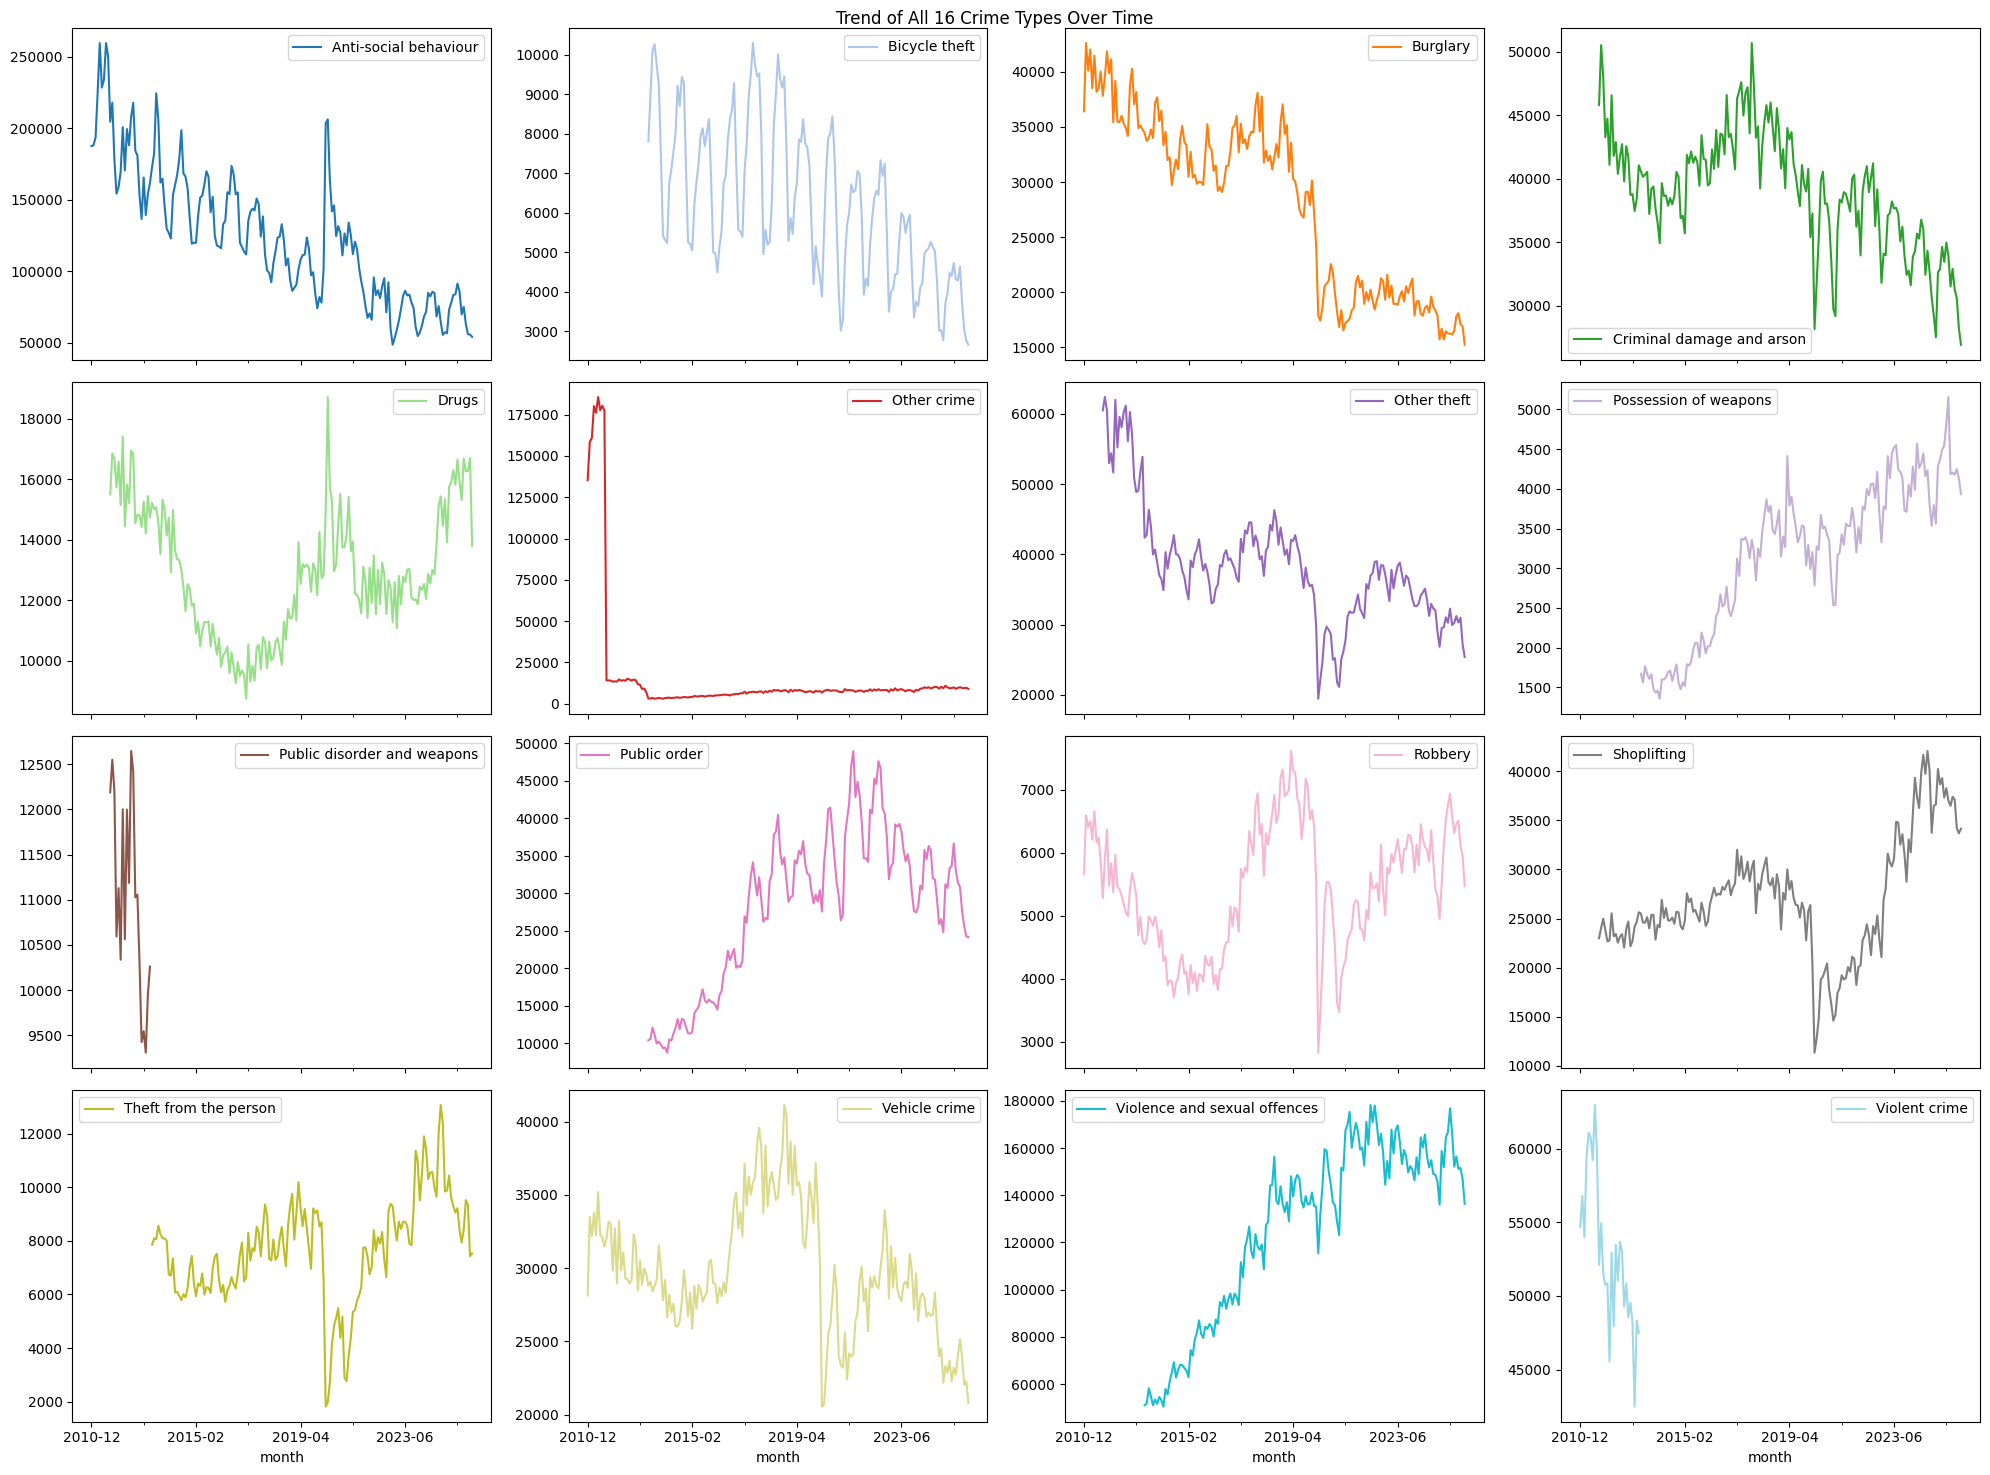

In [65]:
#4b graph raw counts against time per crime type

#query total counts per month per crime type
query = """
SELECT month, crime_type, COUNT(*) as incident_count
FROM street_crimes
GROUP BY month, crime_type
ORDER BY month;
"""
df = pd.read_sql(query, conn)

#turns month into index and creates 16 cols of crime counts
df_pivot = df.pivot(index='month', columns='crime_type', values='incident_count')

#plotting all 16
ax = df_pivot.plot(
    subplots=True,
    layout=(4, 4),
    figsize=(20, 15),
    sharex=True,
    colormap= "tab20",
    title="Trend of All 16 Crime Types Over Time"
)
plt.tight_layout()
plt.savefig('../data/crime_trends.png', dpi=300, bbox_inches='tight')
plt.show()

In [69]:
#5a double check nothing is empty in lsoa_demographics
null_query = """
SELECT 
    COUNT(*) - COUNT(lsoa_code) as missing_lsoa_code,
    COUNT(*) - COUNT(income_score) as missing_income,
    COUNT(*) - COUNT(employment_score) as missing_employment,
    COUNT(*) - COUNT(education_score) as missing_education,
    COUNT(*) - COUNT(health_score) as missing_health,
    COUNT(*) - COUNT(barrier_score) as missing_barrier,
    COUNT(*) - COUNT(living_score) as missing_living,
    COUNT(*) - COUNT(pop) as missing_pop,
    COUNT(*) - COUNT(child_pop) as missing_child,
    COUNT(*) - COUNT(old_pop) as missing_old,
    COUNT(*) - COUNT(working_pop) as missing_working
FROM lsoa_demographics;
"""
null_df = pd.read_sql(null_query, conn)
null_percentages = (null_df / total_rows) * 100
display(null_percentages.round(2).astype(str) + '%')

,missing_lsoa_code,missing_income,missing_employment,missing_education,missing_health,missing_barrier,missing_living,missing_pop,missing_child,missing_old,missing_working
0,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


In [74]:
#5 perform transformations on lsoa_demographics to match plan

#loading table into df
df = pd.read_sql("SELECT * FROM lsoa_demographics;", conn)

#calculate the scores as written in plan
df['econ_score'] = (df['income_score'] + df['employment_score']) / 2
df['infrastructure_score'] = (df['education_score'] + df['barrier_score'] + df['living_score']) / 3

#calculate pop percentages per group
df['percent_working'] = df['working_pop'] / df['pop']
df['percent_child'] = df['child_pop'] / df['pop']
df['percent_old'] = df['old_pop'] / df['pop']

#filter df to only keep the important cols
columns_to_keep = [
    'lsoa_code', 
    'pop', 
    'econ_score', 
    'infrastructure_score', 
    'health_score', 
    'percent_working', 
    'percent_child', 
    'percent_old'
]
df_clean = df[columns_to_keep]

#overwrite old table
df_clean.to_sql("lsoa_demographics", conn, if_exists="replace", index=False)

#re-apply index just in case it's dropped in process
conn.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_lsoa_code ON lsoa_demographics(lsoa_code);")
display(df_clean.head())


,lsoa_code,pop,econ_score,infrastructure_score,health_score,percent_working,percent_child,percent_old
0,E01000001,1795,0.0135,26.766333,-1.771,0.695265,0.083008,0.289694
1,E01000002,1671,0.0140,16.920667,-1.549,0.792340,0.048474,0.231598
2,E01000003,1896,0.0855,18.055667,-0.292,0.774789,0.071730,0.227848
3,E01000005,1737,0.1575,27.056667,0.436,0.833621,0.101900,0.092113
4,E01000006,1837,0.2315,31.027667,-0.372,0.685901,0.216113,0.122482
